In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

df = pd.read_csv(
    "/content/baltimore_crime_counts_2023.csv",
    parse_dates=["CrimeDateTime"],
    index_col=0
)

df.head()

,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING
CrimeDateTime,,,,,,,,,,,,,
2011-01-01,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN
2011-01-02,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN
2011-01-03,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN
2011-01-04,29,1,11,12,12,29,10,4,0,0.0,NaN,NaN,NaN
2011-01-05,30,0,9,14,28,26,10,6,2,0.0,NaN,NaN,NaN


In [10]:
crimes = ['LARCENY','LARCENY FROM AUTO', 'AUTO THEFT','SHOOTING','ROBBERY - CARJACKING']
crimes_ts = df[crimes].copy()
crimes_ts.head()

,LARCENY,LARCENY FROM AUTO,AUTO THEFT,SHOOTING,ROBBERY - CARJACKING
CrimeDateTime,,,,,
2011-01-01,39,27,15,NaN,NaN
2011-01-02,20,20,5,NaN,NaN
2011-01-03,19,16,7,NaN,NaN
2011-01-04,29,12,10,NaN,NaN
2011-01-05,30,14,10,NaN,NaN


In [11]:
crimes_ts.isna().sum()

,0
LARCENY,0
LARCENY FROM AUTO,0
AUTO THEFT,0
SHOOTING,384
ROBBERY - CARJACKING,7


In [12]:
## fill null values with 0
crimes_ts = crimes_ts.fillna(0)
crimes_ts

,LARCENY,LARCENY FROM AUTO,AUTO THEFT,SHOOTING,ROBBERY - CARJACKING
CrimeDateTime,,,,,
2011-01-01,39,27,15,0.0,0.0
2011-01-02,20,20,5,0.0,0.0
2011-01-03,19,16,7,0.0,0.0
2011-01-04,29,12,10,0.0,0.0
2011-01-05,30,14,10,0.0,0.0
...,...,...,...,...,...
2024-12-25,15,8,1,0.0,1.0
2024-12-26,21,10,4,2.0,2.0
2024-12-27,20,6,8,5.0,0.0


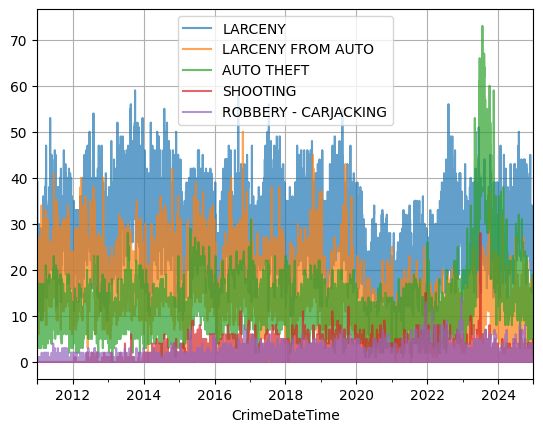

In [13]:
crimes_ts.plot(grid=True,alpha=0.7);

##Identifying Seasonality

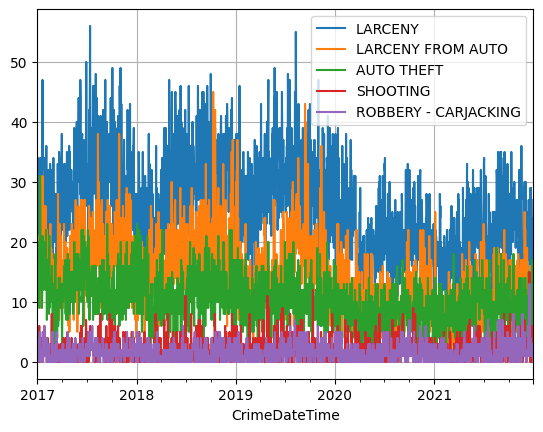

In [14]:
plot_df = crimes_ts.loc['2017':'2021']
plot_df.plot(grid=True);

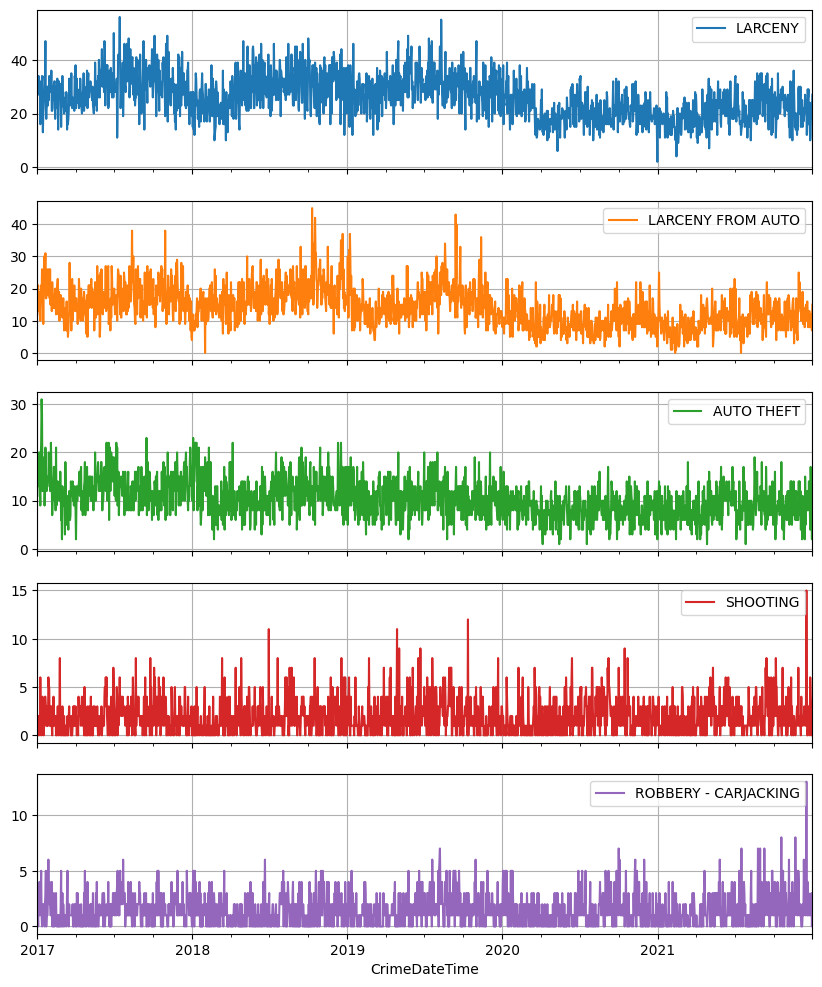

In [15]:
plot_df.plot(subplots=True,figsize=(10,12),grid=True);

##Resampling to a Larger Frequency

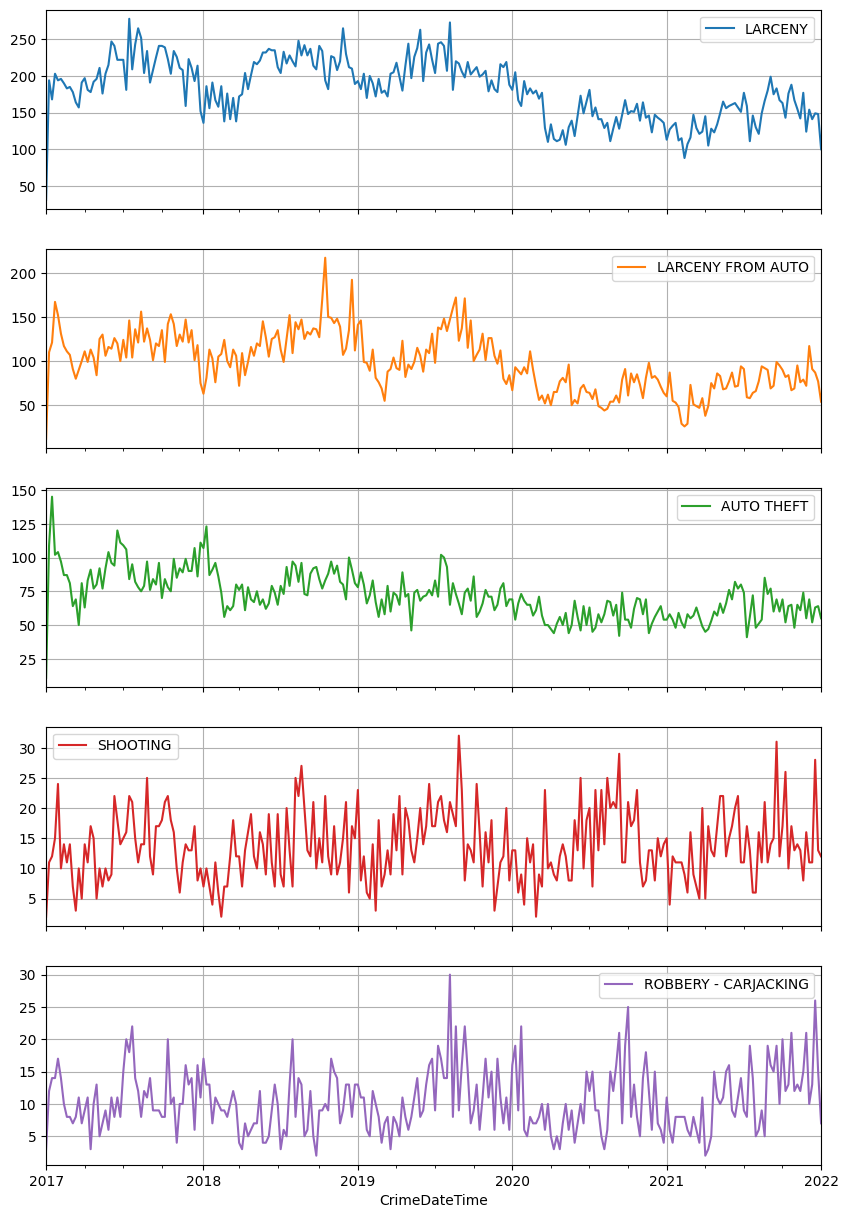

In [16]:
plot_df_W = crimes_ts.loc['2017':'2021'].resample('W').sum()
plot_df_W.plot(grid=True,subplots=True,figsize=(10,15));

##Using Rolling Mean to Smooth Time Series

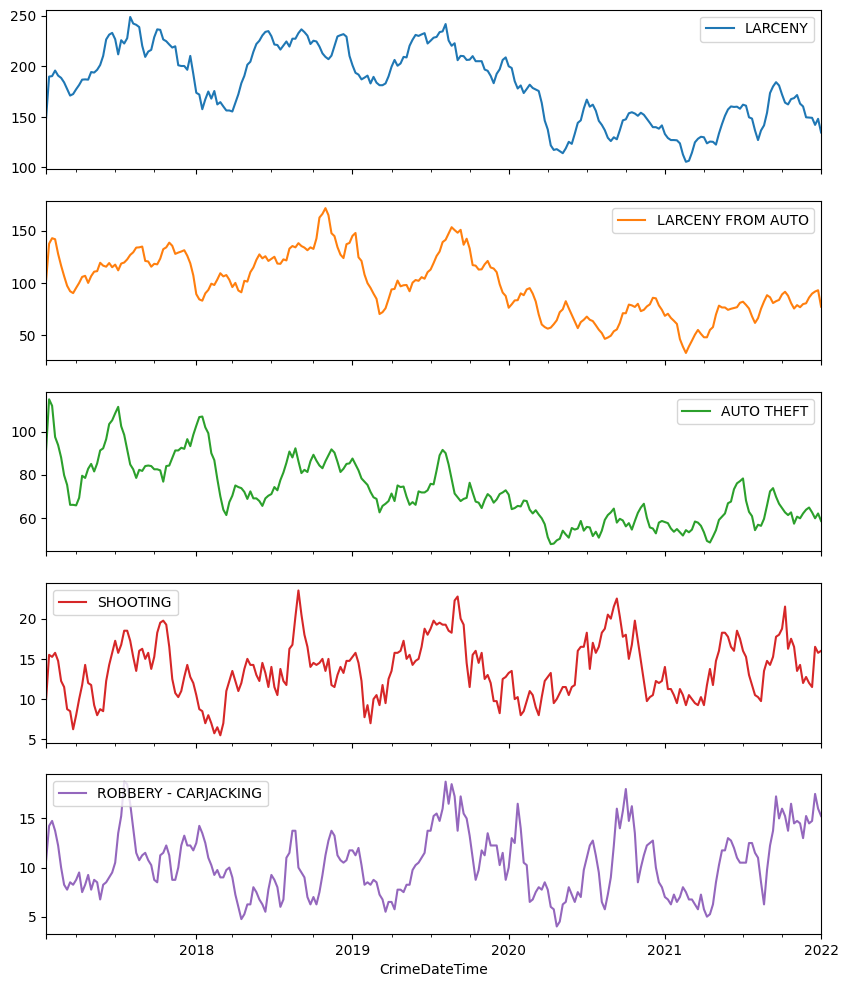

In [17]:
plot_df_W.rolling(4).mean().dropna().plot(subplots=True,figsize=(10,12));

#Seasonal Decomposition

In [18]:
# import the statsmodels time series analysis api module
import statsmodels.tsa.api as tsa
tsa

<module 'statsmodels.tsa.api' from '/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/api.py'>

<Axes: title={'center': 'LARCENY FROM AUTO'}, xlabel='CrimeDateTime'>

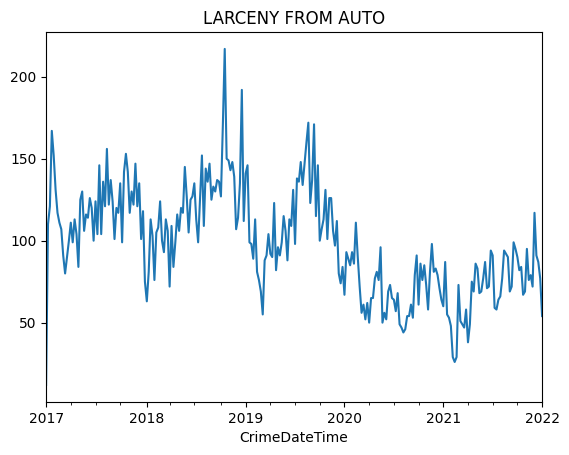

In [19]:
crime_type = "LARCENY FROM AUTO"
ts = plot_df_W[crime_type]
ts.plot(title=crime_type)

#Visualizing Decomposed Results

In [21]:
decomp = tsa.seasonal_decompose(ts)
decomp

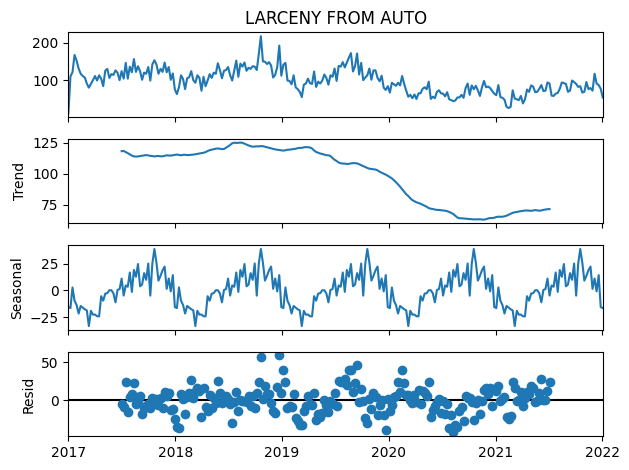

In [22]:
fig = decomp.plot()

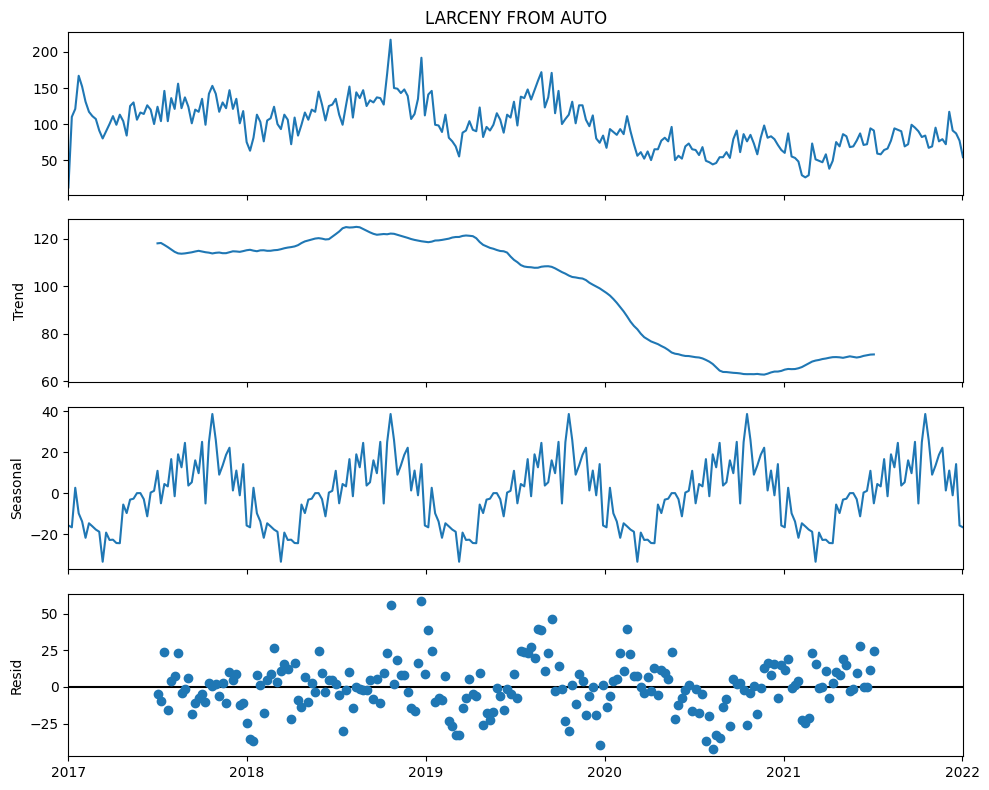

In [23]:
fig = decomp.plot()
fig.set_size_inches(10,8)
fig.tight_layout()

#Inspecting the Individual Components

In [24]:
decomp.trend

,trend
CrimeDateTime,
2017-01-01,NaN
2017-01-08,NaN
2017-01-15,NaN
2017-01-22,NaN
2017-01-29,NaN
...,...
2021-12-05,NaN
2021-12-12,NaN
2021-12-19,NaN


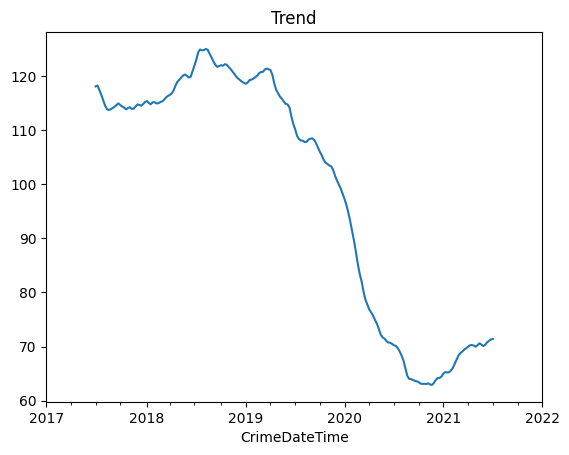

In [25]:
decomp.trend.plot(title='Trend');

#Decomposed - Seasonal

In [26]:
decomp.seasonal.head()

,seasonal
CrimeDateTime,
2017-01-01,-15.614784
2017-01-08,-16.511418
2017-01-15,2.728966
2017-01-22,-9.701322
2017-01-29,-13.667668


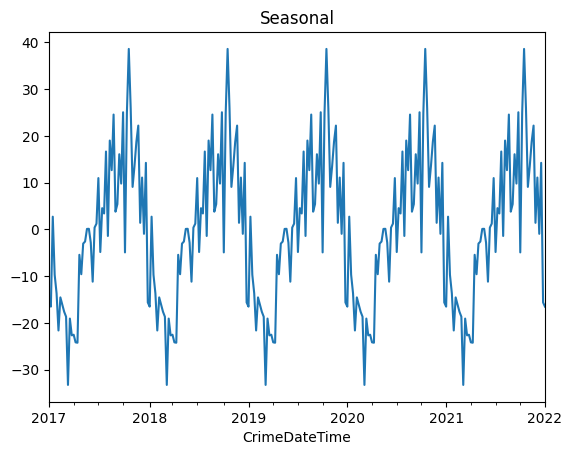

In [27]:
decomp.seasonal.plot(title='Seasonal');

#Decomposed Residuals

In [28]:
decomp.resid.head()

,resid
CrimeDateTime,
2017-01-01,NaN
2017-01-08,NaN
2017-01-15,NaN
2017-01-22,NaN
2017-01-29,NaN


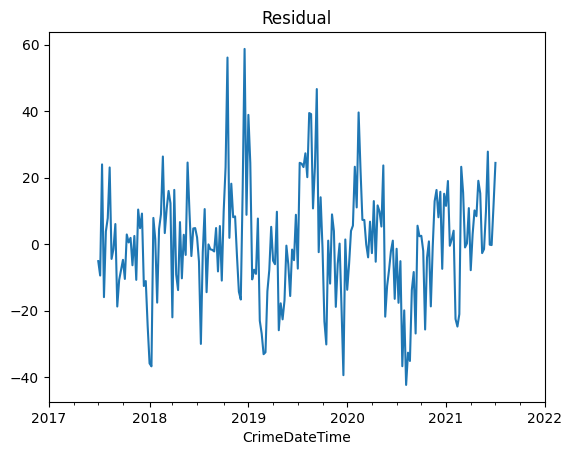

In [29]:
decomp.resid.plot(title='Residual');

#Decomposition's Separate Components

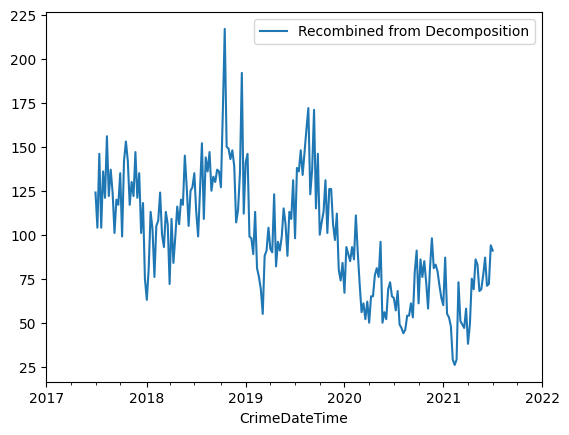

In [30]:
# Adding decomposition components together
ts_model = decomp.trend + decomp.seasonal + decomp.resid
# Visualize the result
ax = ts_model.plot(label='Recombined from Decomposition')
ax.legend()

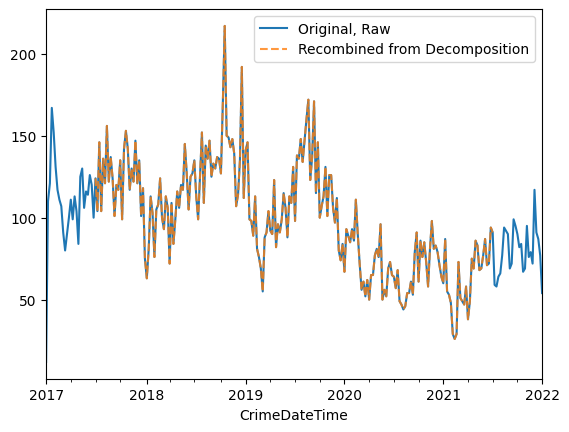

In [31]:
ax = ts.plot(label='Original, Raw')
ts_model.plot(label='Recombined from Decomposition',ax=ax, ls='--', alpha=0.8)
ax.legend();

#Assessing Seasonal Contributions

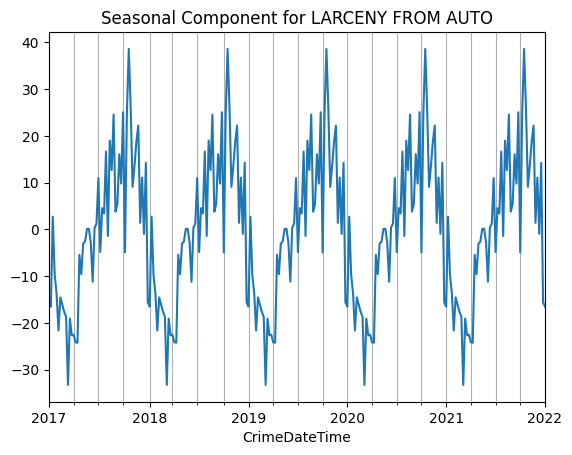

In [32]:
seasonal = decomp.seasonal
ax = seasonal.plot(title=f'Seasonal Component for {crime_type}');
ax.grid(which='both', axis='x')

In [34]:
import matplotlib.pyplot as plt

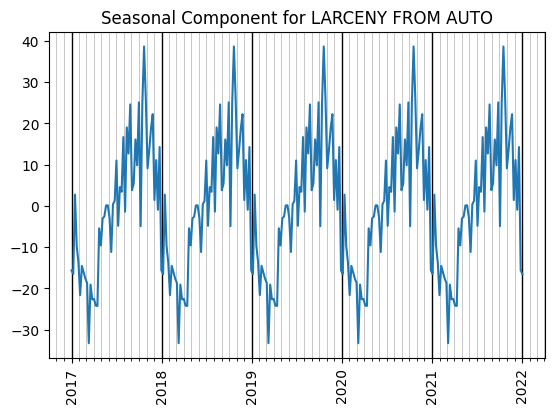

In [35]:
import matplotlib.dates as mdates
minor_loc = mdates.MonthLocator()
fig, ax = plt.subplots()
ax.plot(seasonal)
ax.set(title=f'Seasonal Component for {crime_type}');
ax.xaxis.set_minor_locator(minor_loc)
ax.grid(which='major', axis='x',lw=1, color='k')
ax.grid(which='minor',axis='x',lw=0.5)
fig.autofmt_xdate(rotation=90, ha='center')

#Determining Seasonal Fluctuation - Magnitude

In [36]:
seasonal.max()

38.613581730769226

In [37]:
seasonal.min()

-33.259014423076934

In [38]:
magnitude = seasonal.max() - seasonal.min()
magnitude

71.87259615384616

#Determining the Duration of a Season

In [39]:
seasonal.idxmax()

Timestamp('2017-10-22 00:00:00')

In [40]:
seasonal.idxmin()

Timestamp('2017-03-12 00:00:00')

#Annotating Periods

In [41]:
import matplotlib.dates as mdates
def plot_seasonal(seasonal):
    minor_loc = mdates.MonthLocator()
    fig, ax = plt.subplots()
    ax.plot(seasonal)
    ax.set(title=f'Seasonal Component for {crime_type}');
    ax.xaxis.set_minor_locator(minor_loc)
    ax.grid(which='major', axis='x',lw=1, color='k')
    ax.grid(which='minor',axis='x',lw=0.5)
    fig.autofmt_xdate(rotation=90, ha='center')

    return fig, ax

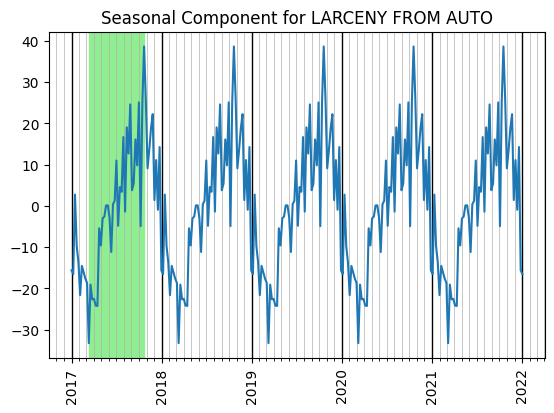

In [42]:
fig, ax = plot_seasonal(seasonal)
ax.axvspan(seasonal.idxmin(),seasonal.idxmax(), color='lightgreen');

In [43]:
delta = seasonal.idxmax() - seasonal.idxmin()
delta

Timedelta('224 days 00:00:00')

#Using Scipy's  find_peakes() Function.

In [44]:
from scipy.signal import find_peaks
peaks, props = find_peaks(seasonal, height=seasonal.max())

In [45]:
peaks


array([ 42,  94, 146, 198, 250])

In [46]:
props

{'peak_heights': array([38.61358173, 38.61358173, 38.61358173, 38.61358173, 38.61358173])}

In [47]:
peak_dates = seasonal.index[peaks]
peak_dates

DatetimeIndex(['2017-10-22', '2018-10-21', '2019-10-20', '2020-10-18',
               '2021-10-17'],
              dtype='datetime64[ns]', name='CrimeDateTime', freq=None)

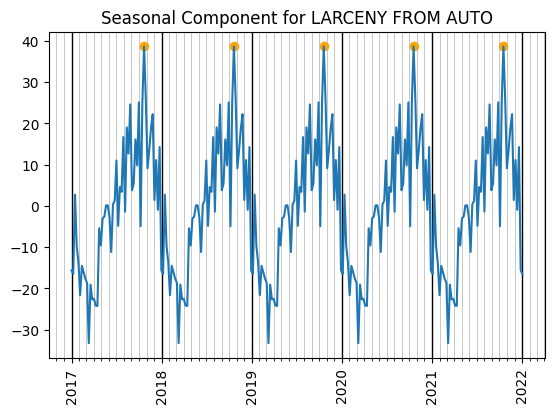

In [48]:
fig,ax = plot_seasonal(seasonal)
ax.scatter(peak_dates, props['peak_heights'], color='orange');

In [49]:
peak_dates

DatetimeIndex(['2017-10-22', '2018-10-21', '2019-10-20', '2020-10-18',
               '2021-10-17'],
              dtype='datetime64[ns]', name='CrimeDateTime', freq=None)

In [50]:
period = peak_dates[1] - peak_dates[0]
period

Timedelta('364 days 00:00:00')

In [51]:
periods = []
for i in range(len(peak_dates)-1):
    delta = peak_dates[i+1] - peak_dates[i]
    periods.append(delta)
periods

[Timedelta('364 days 00:00:00'),
 Timedelta('364 days 00:00:00'),
 Timedelta('364 days 00:00:00'),
 Timedelta('364 days 00:00:00')]

#Final Annotation

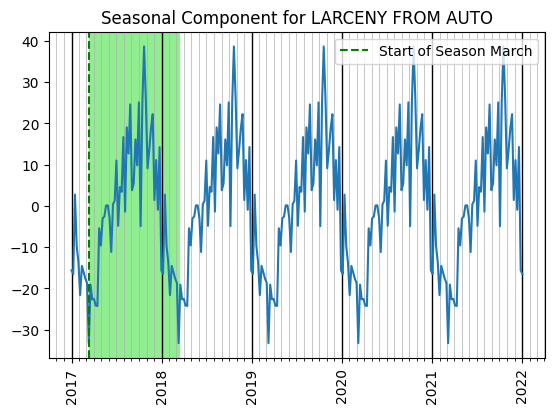

In [52]:
fig, ax = plot_seasonal(seasonal)
season_start = seasonal.idxmin()
ax.axvspan( season_start, season_start +period, color='lightgreen')
ax.axvline(season_start, color='green', ls='--',
           label=f"Start of Season {season_start.strftime('%B')}")
ax.legend();

In [53]:
seasonal.max() - seasonal.min()

71.87259615384616